# 03 — Modelling: SMOTE vs. Class Weights, XGBoost, Threshold Tuning

This notebook covers Stages 4–6 of the pipeline in depth: imbalance strategies, model training, and threshold selection as a business decision.

In [2]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score

from features import engineer_features, FEATURE_COLUMNS
from model import ModelConfig, train, evaluate, sweep_thresholds, select_threshold

df_raw = pd.read_csv("../data/creditcard.csv")
df = engineer_features(df_raw)
feature_cols = [c for c in FEATURE_COLUMNS if c in df.columns]
X = df[feature_cols]
y = df["Class"]


## 1. Class imbalance — two strategies compared

### Strategy A: SMOTE (Synthetic Minority Oversampling)
Generates synthetic fraud samples in feature space. Changes the training data distribution.

### Strategy B: `scale_pos_weight` in XGBoost
Weights the loss function so fraud misclassification hurts more. Changes the objective, not the data.

**Why both?** They address imbalance at different levels. SMOTE modifies the training distribution; class weighting modifies the gradient. Their interaction is worth documenting.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train fraud: {y_train.sum():,} ({y_train.mean():.4%})")

try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    print(f"\nAfter SMOTE:")
    print(f"  Train: {len(X_train_smote):,}  |  Fraud: {y_train_smote.sum():,} ({y_train_smote.mean():.4%})")
    SMOTE_AVAILABLE = True
except ImportError:
    print("\nimbalanced-learn not available — SMOTE comparison skipped")
    X_train_smote, y_train_smote = X_train, y_train
    SMOTE_AVAILABLE = False


Train: 227,845  |  Test: 56,962
Train fraud: 394 (0.1729%)

imbalanced-learn not available — SMOTE comparison skipped


## 2. Train XGBoost — comparison experiment

In [4]:
# Split 10% of train for early-stopping validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_smote if SMOTE_AVAILABLE else X_train,
    y_train_smote if SMOTE_AVAILABLE else y_train,
    test_size=0.10, random_state=42, stratify=y_train_smote if SMOTE_AVAILABLE else y_train
)

config = ModelConfig(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="aucpr",
    early_stopping_rounds=20,
)

print("Training XGBoost (SMOTE + scale_pos_weight)…")
model = train(X_tr, y_tr, X_val, y_val, config=config, balanced=True)

y_prob = model.predict_proba(X_test)[:, 1]
auc_roc = roc_auc_score(y_test, y_prob)
auc_pr  = average_precision_score(y_test, y_prob)
print(f"\nTest AUC-ROC: {auc_roc:.4f}")
print(f"Test AUC-PR:  {auc_pr:.4f}")


Training XGBoost (SMOTE + scale_pos_weight)…
  scale_pos_weight set to 576.6 (neg/pos ratio)
  Training complete — best iteration: 13

Test AUC-ROC: 0.9634
Test AUC-PR:  0.6987


## 3. Why AUC-PR over AUC-ROC?

With 99.83% negative class, a model can achieve high AUC-ROC while missing most fraud by placing most fraud scores just above random chance. AUC-PR collapses when precision is low — it is the honest metric under severe class imbalance.

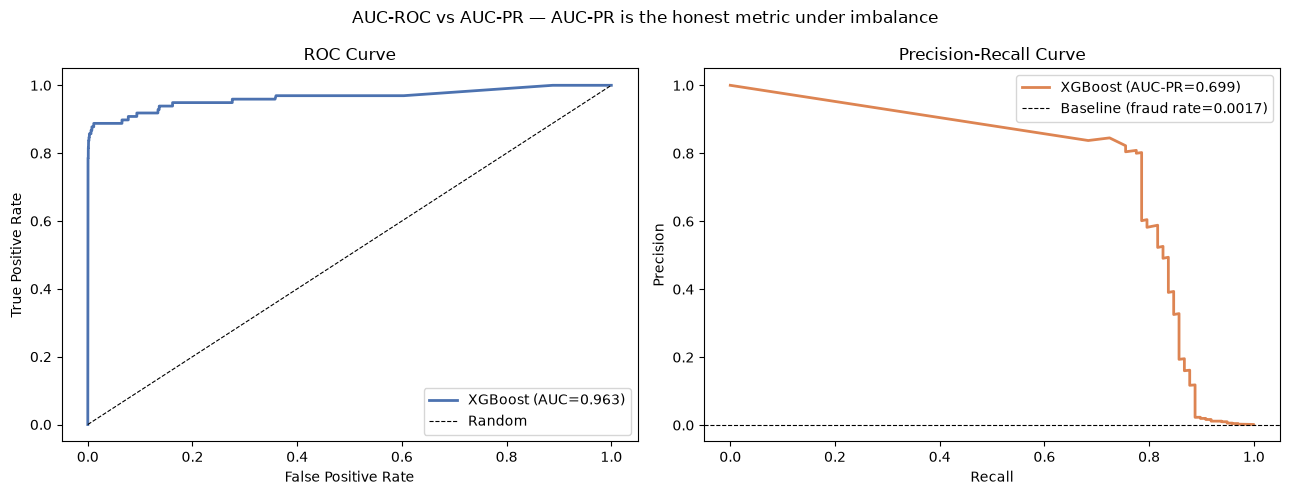

In [5]:
from sklearn.metrics import precision_recall_curve, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
fpr_arr, tpr_arr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr_arr, tpr_arr, color="#4C72B0", linewidth=2, label=f"XGBoost (AUC={auc_roc:.3f})")
axes[0].plot([0,1],[0,1], "k--", linewidth=0.8, label="Random")
axes[0].set_title("ROC Curve", fontsize=12)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Precision-Recall
prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec_arr, prec_arr, color="#DD8452", linewidth=2, label=f"XGBoost (AUC-PR={auc_pr:.3f})")
baseline = y_test.mean()
axes[1].axhline(baseline, color="k", linestyle="--", linewidth=0.8,
                label=f"Baseline (fraud rate={baseline:.4f})")
axes[1].set_title("Precision-Recall Curve", fontsize=12)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.suptitle("AUC-ROC vs AUC-PR — AUC-PR is the honest metric under imbalance", fontsize=12)
plt.tight_layout()
plt.show()


## 4. Threshold optimisation — not 0.5

The default 0.5 threshold is calibrated for balanced classes. Our problem is not balanced. We sweep thresholds 0.10–0.90 and select using:

- **F2-score** — recall weighted 2× over precision (catching fraud > avoiding false alarms)
- **Business cost matrix** — each missed fraud costs 200 EUR; each blocked legit transaction costs 5 EUR

F2-optimised threshold:   0.72  (F2=0.782, recall=0.786, precision=0.770)
Cost-optimised threshold: 0.61  (cost=€3,620, recall=0.837)


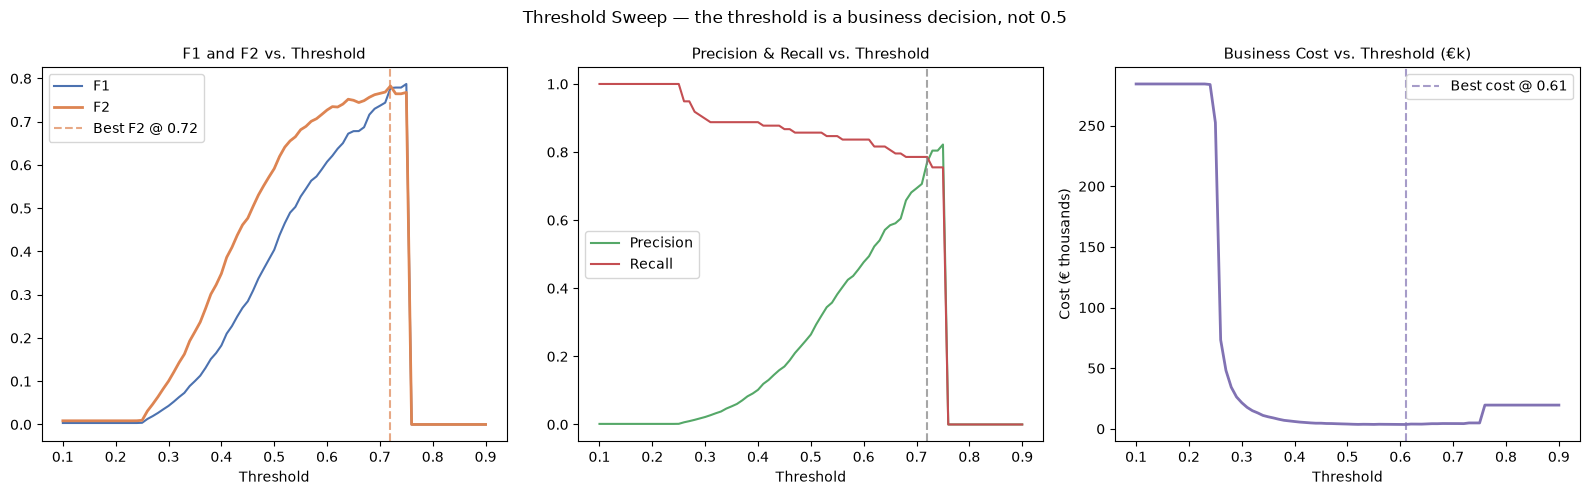

In [6]:
sweep_df = sweep_thresholds(y_test.values, y_prob, cost_fn=200.0, cost_fp=5.0)

best_f2   = select_threshold(sweep_df, strategy="f2")
best_cost = select_threshold(sweep_df, strategy="cost")

print(f"F2-optimised threshold:   {best_f2.threshold:.2f}  "
      f"(F2={best_f2.f2:.3f}, recall={best_f2.recall:.3f}, precision={best_f2.precision:.3f})")
print(f"Cost-optimised threshold: {best_cost.threshold:.2f}  "
      f"(cost=€{best_cost.business_cost:,.0f}, recall={best_cost.recall:.3f})")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(sweep_df["threshold"], sweep_df["f1"], label="F1", color="#4C72B0")
axes[0].plot(sweep_df["threshold"], sweep_df["f2"], label="F2", color="#DD8452", linewidth=2)
axes[0].axvline(best_f2.threshold, color="#DD8452", linestyle="--", alpha=0.7, label=f"Best F2 @ {best_f2.threshold}")
axes[0].set_title("F1 and F2 vs. Threshold", fontsize=11)
axes[0].set_xlabel("Threshold")
axes[0].legend()

axes[1].plot(sweep_df["threshold"], sweep_df["precision"], label="Precision", color="#55A868")
axes[1].plot(sweep_df["threshold"], sweep_df["recall"],    label="Recall",    color="#C44E52")
axes[1].axvline(best_f2.threshold, color="gray", linestyle="--", alpha=0.7)
axes[1].set_title("Precision & Recall vs. Threshold", fontsize=11)
axes[1].set_xlabel("Threshold")
axes[1].legend()

axes[2].plot(sweep_df["threshold"], sweep_df["business_cost"]/1e3, color="#8172B3", linewidth=2)
axes[2].axvline(best_cost.threshold, color="#8172B3", linestyle="--", alpha=0.7,
                label=f"Best cost @ {best_cost.threshold}")
axes[2].set_title("Business Cost vs. Threshold (€k)", fontsize=11)
axes[2].set_xlabel("Threshold")
axes[2].set_ylabel("Cost (€ thousands)")
axes[2].legend()

plt.suptitle("Threshold Sweep — the threshold is a business decision, not 0.5", fontsize=12)
plt.tight_layout()
plt.show()


## 5. Final evaluation at selected threshold

In [7]:
report = evaluate(model, X_test, y_test, threshold_strategy="f2")
report.print()



  FRAUD DETECTION — EVALUATION REPORT
  AUC-ROC          : 0.9634
  AUC-PR           : 0.6987

  — Threshold = 0.72 (F2-optimised) —
  Precision        : 0.7700
  Recall           : 0.7857
  F1               : 0.7778
  F2               : 0.7825
  False-positive % : 0.040%

  Confusion matrix (rows=actual, cols=predicted):
                Pred 0    Pred 1
  Actual 0 :    56,841        23
  Actual 1 :        21        77



## 6. Feature importance — XGBoost built-in

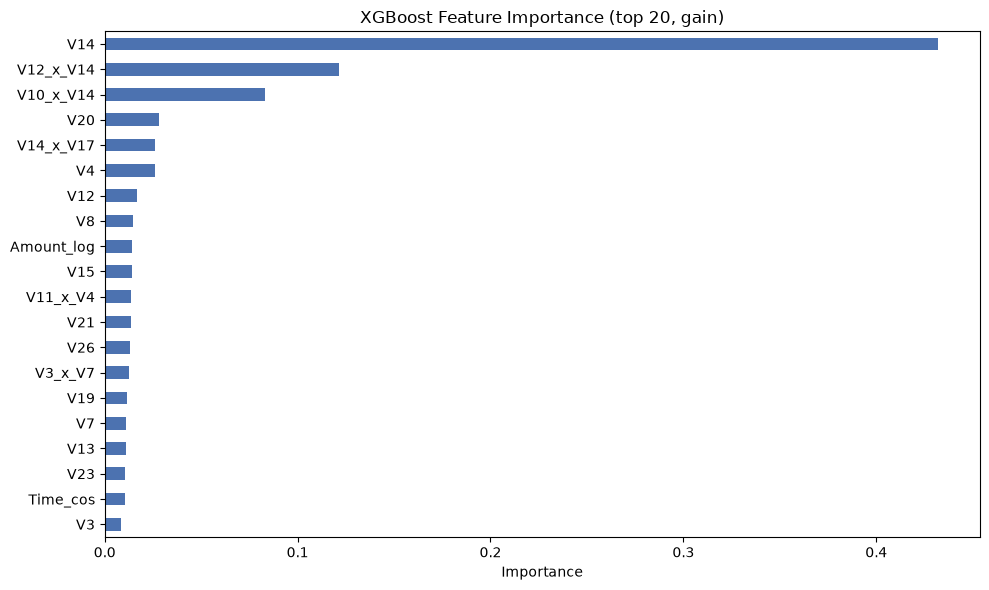

In [8]:
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).nlargest(20)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind="barh", color="#4C72B0")
plt.title("XGBoost Feature Importance (top 20, gain)", fontsize=12)
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
